In [ ]:
!pip install ultralytics mlflow dagshub ray[tune] -q

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
DATASET_PATH = '/content/drive/MyDrive/obj_detection/aquarium_pretrain'
NOTEBOOK_NAME = 'obj_detection_yolo.ipynb'

import os
print("Dataset folders:", os.listdir(DATASET_PATH))
print("data.yaml exists:", os.path.exists(f"{DATASET_PATH}/data.yaml"))


Dataset folders: ['README.dataset.txt', 'data.yaml', 'README.roboflow.txt', 'train', 'valid', 'test']
data.yaml exists: True


In [ ]:
!ls {DATASET_PATH}

data.yaml  README.dataset.txt  README.roboflow.txt  test  train  valid


In [ ]:
import os
import mlflow
import dagshub
from ultralytics import YOLO
import yaml
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
from google.colab import files
import glob



In [ ]:
DAGSHUB_REPO_OWNER = "arsapkota500"
DAGSHUB_REPO_NAME = "aquarium_yolo"
os.environ["DAGSHUB_TOKEN"] = "******************************"
# Initialize DagsHub connection
dagshub.init(
    repo_owner=DAGSHUB_REPO_OWNER,
    repo_name=DAGSHUB_REPO_NAME,
    mlflow=True,
    # use_token=True
)
mlflow.set_tracking_uri(f"https://dagshub.com/{DAGSHUB_REPO_OWNER}/{DAGSHUB_REPO_NAME}.mlflow")
mlflow.autolog()

Initialized MLflow to track repo "arsapkota500/aquarium_yolo"

Repository arsapkota500/aquarium_yolo initialized!

2025/11/11 06:10:28 WARNING mlflow.spark: With Pyspark >= 3.2, PYSPARK_PIN_THREAD environment variable must be set to false for Spark datasource autologging to work.
2025/11/11 06:10:28 INFO mlflow.tracking.fluent: Autologging successfully enabled for pyspark.


### Augmentation

In [ ]:
def augmentation_config():
  return{
      'hsv_h': 0.015,    # Color jitter (water tint)
        'hsv_s': 0.7,      # Saturation
        'hsv_v': 0.4,      # Brightness
        'degrees': 10.0,   # Slight rotation
        'translate': 0.1,  # Shift
        'scale': 0.5,      # Zoom
        'shear': 2.0,      # Shear
        'perspective': 0.0,
        'flipud': 0.0,
        'fliplr': 0.5,
        'mosaic': 1.0,     # Critical for small objects
        'mixup': 0.1,
        'copy_paste': 0.0

  }

## Hyperparameter Tuning

In [ ]:
def hyperparameters(model, data_yaml, space, iterations=15, grace_period=5):
    with mlflow.start_run(run_name='hyperparameter_tuning'):
        mlflow.log_param('tune_iterations', iterations)
        mlflow.log_param('dataset', data_yaml)
        mlflow.log_param('base_model', model.model_name)

        tune_results = model.tune(
            data=data_yaml,
            space=space,
            iterations=iterations,
            grace_period=grace_period,
            use_ray=True,
            verbose=1
        )

        # Get best result
        best_trial = tune_results.get_best_trial(metric="metrics/mAP50(B)", mode="max")
        best_params = best_trial.last_result
        best_config = best_trial.config

        # Log best params
        mlflow.log_params({f"best_{k}": v for k, v in best_config.items()})
        mlflow.log_metric("best_mAP50", best_trial.last_result["metrics/mAP50(B)"])
        mlflow.log_metric("best_mAP50-95", best_trial.last_result.get("metrics/mAP50-95(B)", 0))

        # Save tuning results
        mlflow.log_artifact(str(tune_results.path))

        print(f"Best mAP50: {best_trial.last_result['metrics/mAP50(B)']:.4f}")

        return best_config

Train with Augmentation

In [ ]:
def train_with_augmentation(model, data_yaml, aug_config, extra_params=None, epochs=50):
    params = {**aug_config, **(extra_params or {})}
    params['epochs'] = epochs
    params['data'] = data_yaml
    params['imgsz'] = 640

    with mlflow.start_run(run_name=f"train-aug-epochs-{epochs}"):
        mlflow.log_params(params)

        # Train the model
        results = model.train(**params)

        # Log metrics
        mlflow.log_metrics({
            'final_mAP50': results.results_dict['metrics/mAP50(B)'],
            'final_mAP50-95': results.results_dict['metrics/mAP50-95(B)'],
            'precision': results.results_dict['metrics/precision(B)'],
            'recall': results.results_dict['metrics/recall(B)']
        })

        # Log the best model
        mlflow.log_artifact(str(results.save_dir / 'weights/best.pt'))

        return results

In [ ]:
# Initialize the model
model = YOLO('yolov8n.pt')

# Path to data.yaml
data_yaml = f"{DATASET_PATH}/data.yaml"

#  hyperparameter search space
space = {
    'lr0': {'distribution': 'uniform', 'min': 0.001, 'max': 0.1},
    'momentum': {'distribution': 'uniform', 'min': 0.6, 'max': 0.98},
    'weight_decay': {'distribution': 'uniform', 'min': 0.0, 'max': 0.001},
    'batch': [8, 16, 32]  # Discrete choices
}

# Get augmentation config
aug_config = augmentation_config()

# Run hyperparameter tuning
# best_params = hyperparameters(model, data_yaml, space, iterations=10)

# End any previous active MLflow runs
mlflow.end_run()

# Train with augmentations and best params
results = train_with_augmentation(model, data_yaml, aug_config, epochs=50)

#  Validate on test set
val_results = model.val()


model.export(format='onnx')  # Or other formats like 'torchscript', etc.

🏃 View run classy-fowl-111 at: https://dagshub.com/arsapkota500/aquarium_yolo.mlflow/#/experiments/1/runs/fd6fc459a8af47098fe3314b96002f53
🧪 View experiment at: https://dagshub.com/arsapkota500/aquarium_yolo.mlflow/#/experiments/1
Ultralytics 8.3.227 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/obj_detection/aquarium_pretrain/data.yaml, degrees=10.0, deterministic=True, device=-1, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lr

2025/11/11 06:11:06 WARNING mlflow.spark: With Pyspark >= 3.2, PYSPARK_PIN_THREAD environment variable must be set to false for Spark datasource autologging to work.
2025/11/11 06:11:06 INFO mlflow.tracking.fluent: Autologging successfully enabled for pyspark.


MLflow: logging run_id(ad4a6507108a43a7b858a967e53b2d72) to https://dagshub.com/arsapkota500/aquarium_yolo.mlflow
MLflow: disable with 'yolo settings mlflow=False'
Image sizes 640 train, 640 val
Using 2 dataloader workers
Logging results to /content/runs/detect/train2
Starting training for 50 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       1/50       2.6G      1.809       3.87      1.471        247        640: 100% ━━━━━━━━━━━━ 28/28 2.3it/s 12.4s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 1.7it/s 2.3s
                   all        127        909     0.0133      0.466     0.0668     0.0301

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       2/50       2.8G      1.786      2.771      1.391        188        640: 100% ━━━━━━━━━━━━ 28/28 3.2it/s 8.9s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 1

'/content/runs/detect/train2/weights/best.onnx'

In [ ]:
MODEL_PATH = results.save_dir / 'weights/best.pt'


In [ ]:
model = YOLO(MODEL_PATH)

In [ ]:
TEST_IMAGE_DIR = f"{DATASET_PATH}/test/images"

all_test_images = list(Path(TEST_IMAGE_DIR).glob('*.jpg')) + \
                  list(Path(TEST_IMAGE_DIR).glob('*.png')) + \
                  list(Path(TEST_IMAGE_DIR).glob('*.jpeg'))

test_images = [str(img) for img in all_test_images[:4]]

print(f"\n✓ Found {len(all_test_images)} test images")
print(f"✓ Selected {len(test_images)} images for detection:")
for i, img_path in enumerate(test_images, 1):
    print(f"  {i}. {Path(img_path).name}")


✓ Found 63 test images
✓ Selected 4 images for detection:
  1. IMG_8490_jpg.rf.1836542cf054c6d303a2dd05d4194d7f.jpg
  2. IMG_8582_MOV-5_jpg.rf.9d7a26fbf145ce39ab0831b4e6bc1f1e.jpg
  3. IMG_8331_jpg.rf.ec024bdf1e9de02b020b5e6505c1c58b.jpg
  4. IMG_3129_jpeg_jpg.rf.90c472dcdf9b6713ec767cc97560ceca.jpg



🔍 Running object detection...

0: 640x640 45 jellyfishs, 5.5ms
1: 640x640 2 fishs, 1 stingray, 5.5ms
2: 640x640 1 fish, 5.5ms
3: 640x640 1 starfish, 5.5ms
Speed: 3.1ms preprocess, 5.5ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict3
✓ Detection complete!
✓ Annotated images saved to: /content/runs/detect/predict3


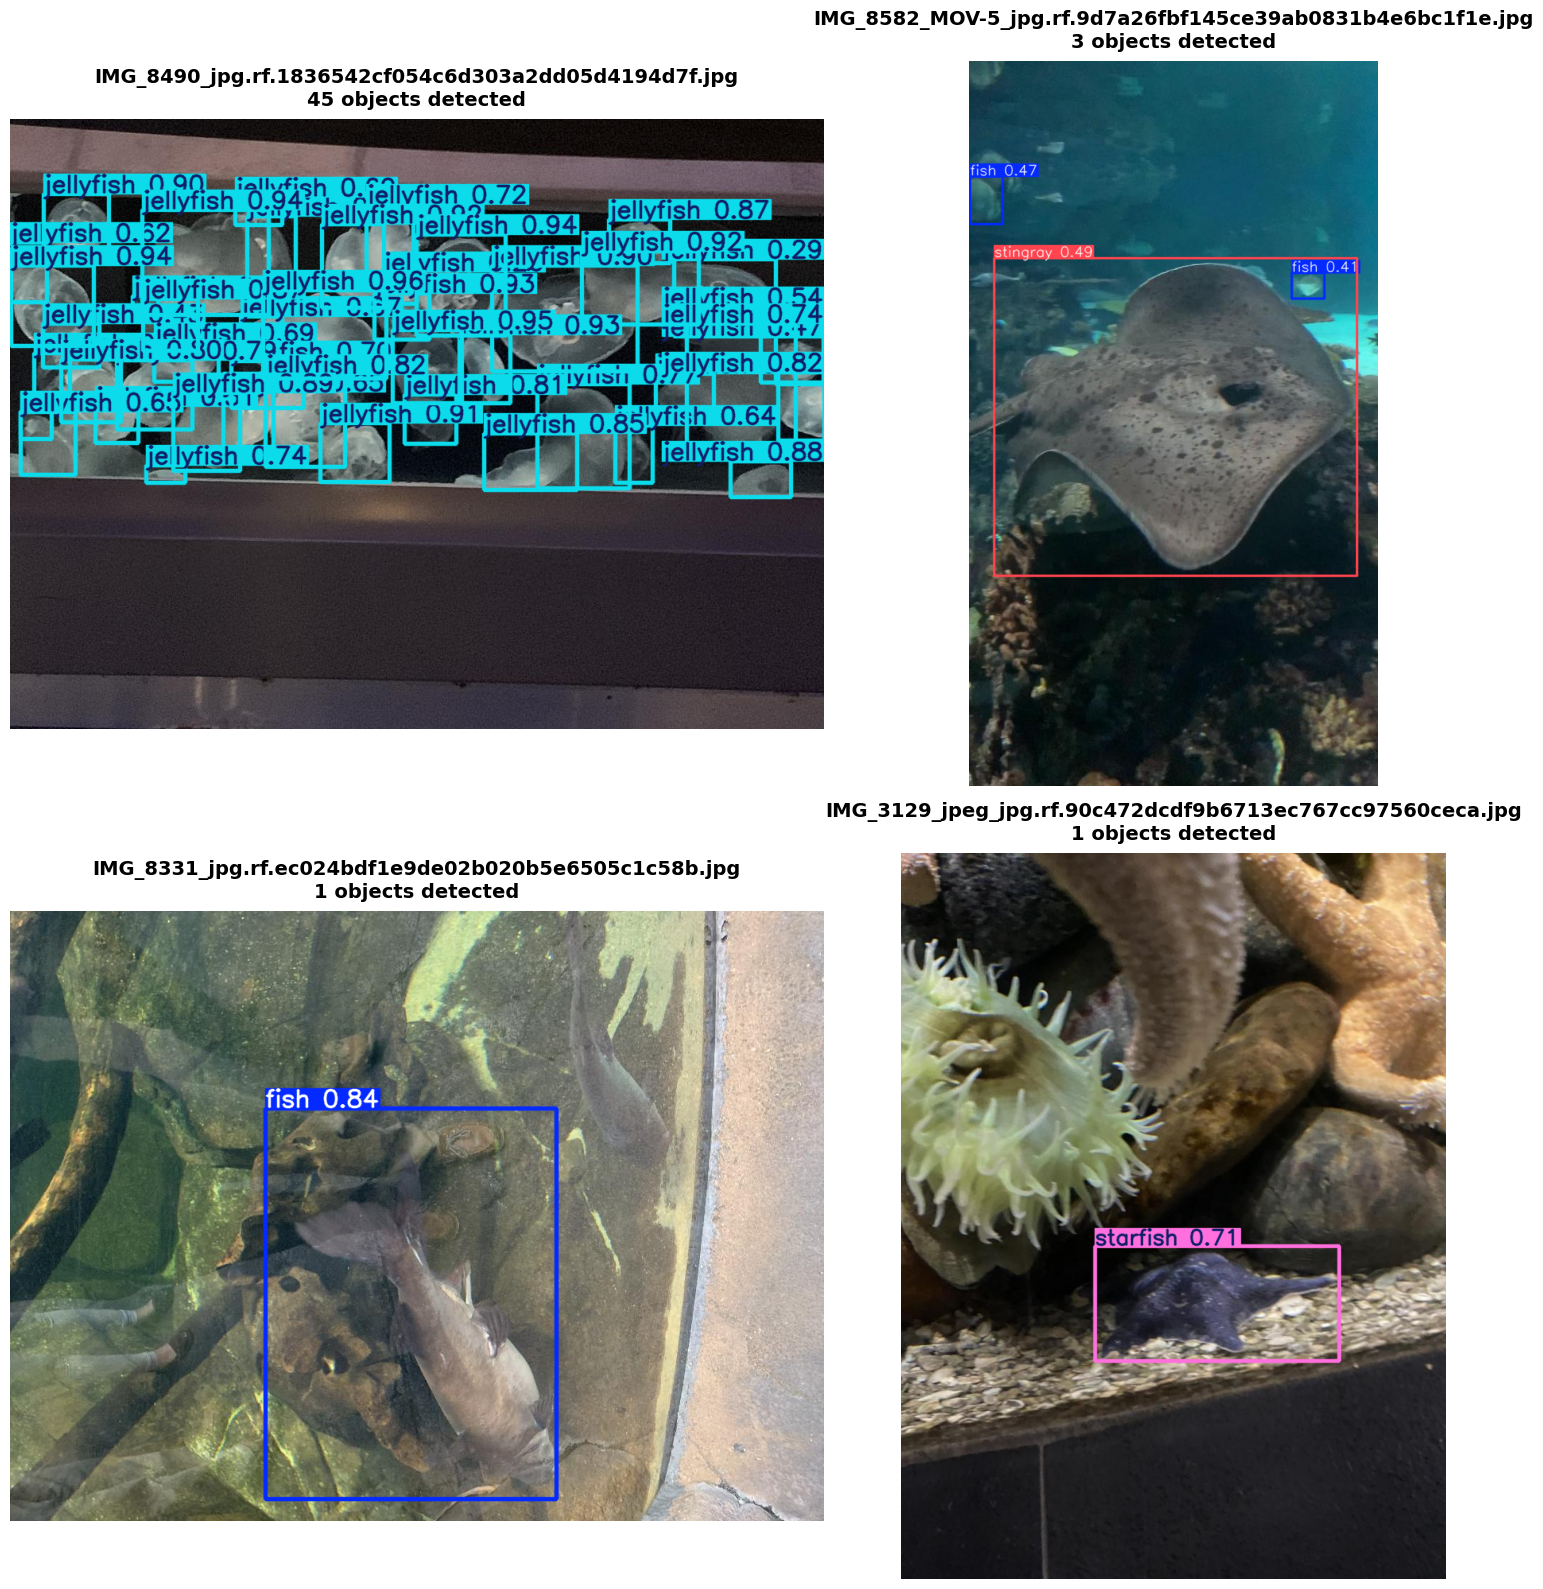


✓ Grid visualization saved: 4_test_predictions.png


In [ ]:
print(f"\n🔍 Running object detection...")

predictions = model.predict(
    source=test_images,
    conf=0.25,
    iou=0.45,
    save=True,
    show_conf=True,
    show_labels=True,
    line_width=3
)

print(f"✓ Detection complete!")
print(f"✓ Annotated images saved to: {predictions[0].save_dir}")

# DISPLAY RESULTS IN 2x2 GRID

fig, axes = plt.subplots(2, 2, figsize=(16, 16))
axes = axes.flatten()

for i, pred in enumerate(predictions):
    # Get annotated image
    img = pred.plot()
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Display
    axes[i].imshow(img_rgb)
    axes[i].axis('off')

    # Title with detections count
    img_name = Path(pred.path).name
    n_detections = len(pred.boxes)
    axes[i].set_title(
        f'{img_name}\n{n_detections} objects detected',
        fontsize=14,
        fontweight='bold',
        pad=10
    )

plt.tight_layout()
plt.savefig('4_test_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ Grid visualization saved: 4_test_predictions.png")

## Test on custom data

In [ ]:
uploaded = files.upload()


Saving fish.avif to fish (1).avif
Saving jellyfish.png to jellyfish (1).png
Saving starfish.webp to starfish (1).webp
Saving stingray.jpeg to stingray (3).jpeg


In [ ]:
os.makedirs('/content/images', exist_ok=True)


In [ ]:
image_paths = []
for filename in uploaded.keys():
    image_paths.append(f'/content/{filename}')

results = model.predict(
        source=image_paths,
        conf=0.25,
        iou=0.45,
        save=True,
        show_conf=True,
        show_labels=True,
        line_width=3,
        verbose=False
    )

print(f"✓ Detection completed!")
print(f"✓ Annotated images saved to: {results[0].save_dir}")

Results saved to /content/runs/detect/predict3
✓ Detection completed!
✓ Annotated images saved to: /content/runs/detect/predict3


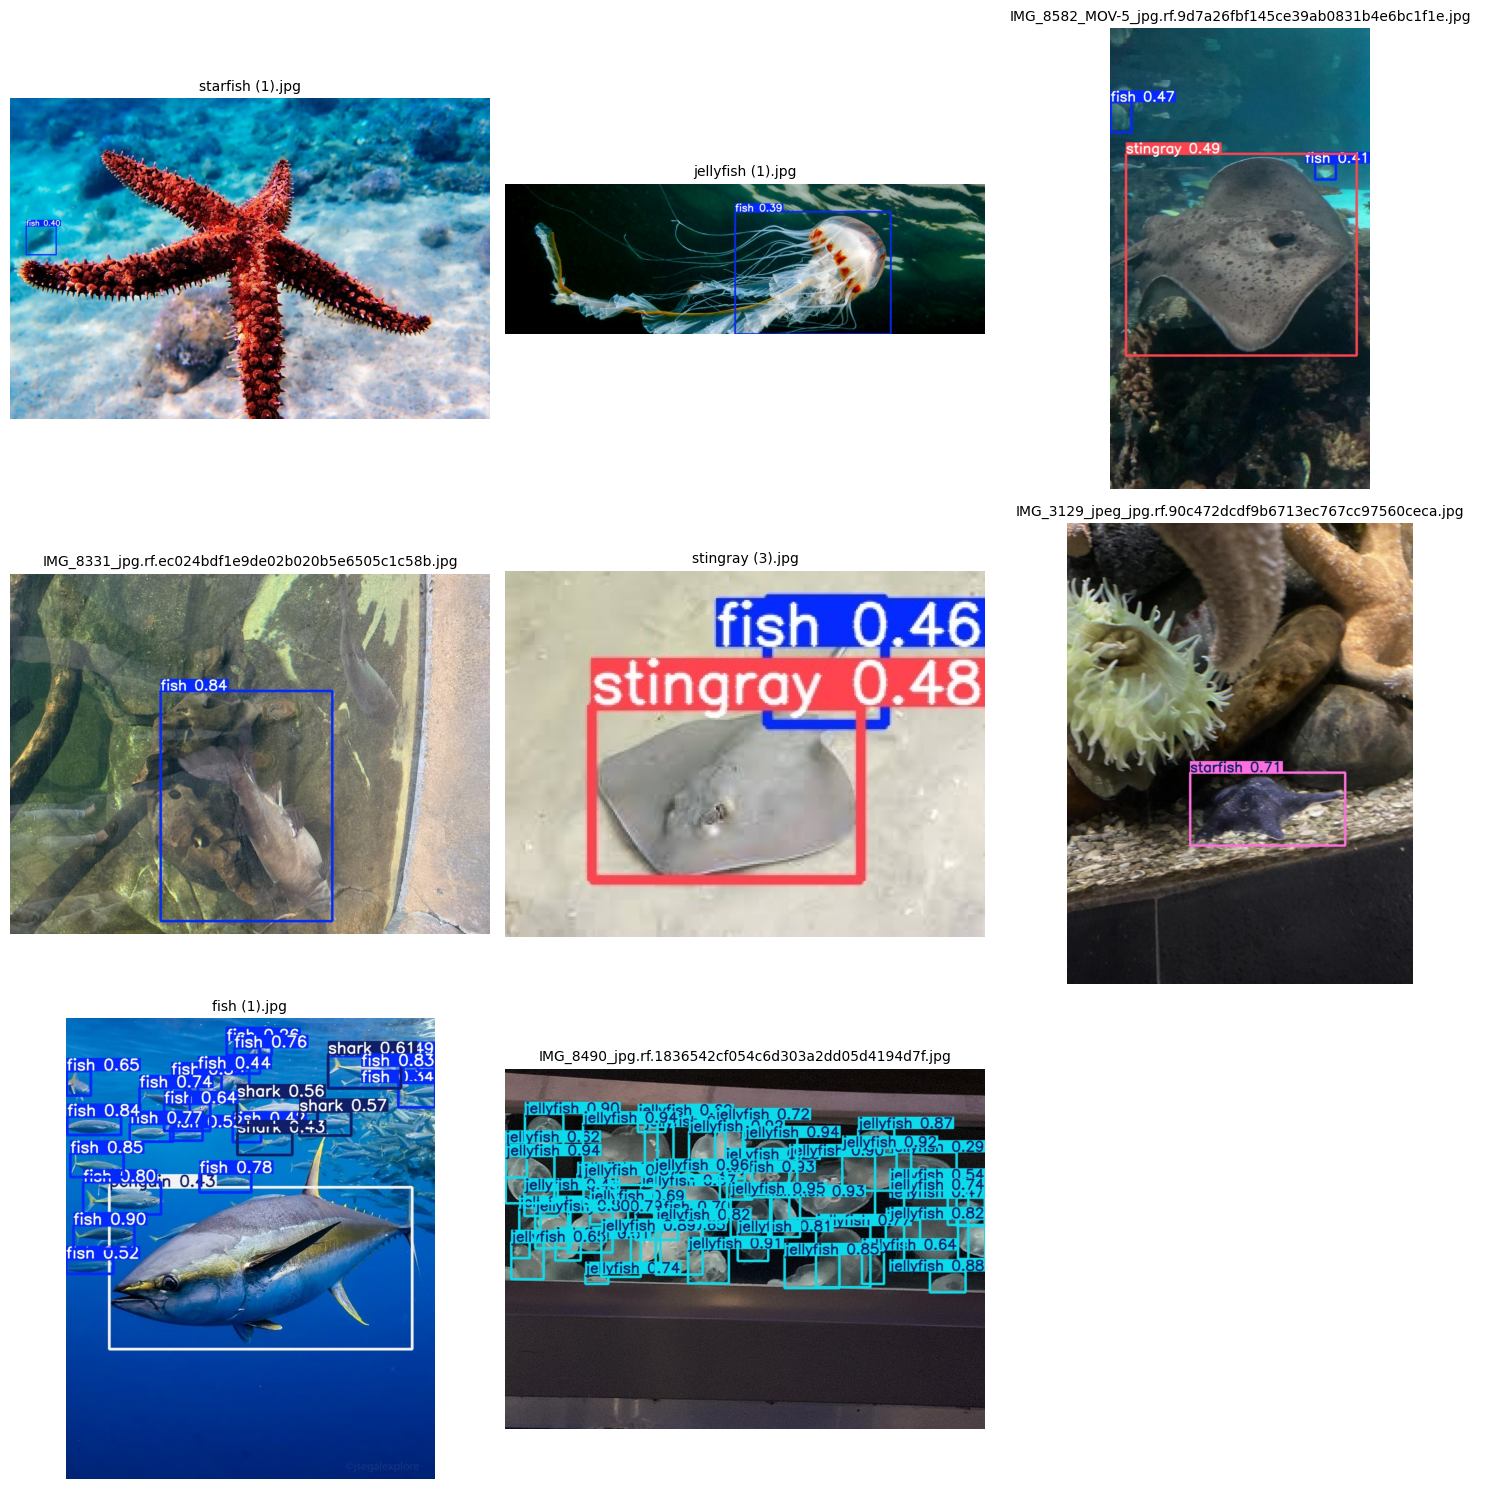

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
import math

# Get the save directory
save_dir = results[0].save_dir

# Get list of image files
image_files = [f for f in os.listdir(save_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png', '.webp', '.avif'))]

# Calculate grid size (e.g., sqrt for roughly square grid)
num_images = len(image_files)
cols = math.ceil(math.sqrt(num_images))
rows = math.ceil(num_images / cols)

# Create figure
fig, axes = plt.subplots(rows, cols, figsize=(15, 15))  # Adjust figsize for larger/smaller display
axes = axes.flatten() if num_images > 1 else [axes]

for i, filename in enumerate(image_files):
    image_path = os.path.join(save_dir, filename)
    img = mpimg.imread(image_path)
    axes[i].imshow(img)
    axes[i].set_title(filename, fontsize=10)
    axes[i].axis('off')  # Hide axes for cleaner view

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()